<a href="https://colab.research.google.com/github/ck1894/NYU-Tandon-CS-GY-6923-Machine-Learning/blob/main/week3_demo_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler # Standardizes features (mean=0, variance=1) for better model performance
from sklearn.datasets import make_classification, make_blobs, make_circles, make_moons # make_* generate synthetic (fake) datasets in memory
import warnings
warnings.filterwarnings('ignore')

## Motivation and Toy Examples

In linear regression, we used the loss
$$L(w) = \|Xw - y\|^2.$$

We can interpret this loss as a log-likelihood model:
$$z = Xw, ~~ p(y \vert z) = N(z, I).$$

Indeed, $$\log p(y \vert X, w) = \log p(y \vert z) = \log N(z, 1) = -\frac 1 2 \|z - y\|^2 + C = -\frac 1 2 \|Xw - y\|^2 + C.$$

### Binary Classification

For bianary classification, our labels are $y_i \in \{0, 1\}.$ The logit $z_i$ is a number: $z_i \in \mathbb{R}$.

We can define the likelihood as

$$ p(y_i \vert z_i) = \sigma(z_i),$$

Where $\sigma$ is the sigmoid function:
$$ \sigma(z_i) = \frac{1}{1 + e^{-z_i}}.$$

## Additional explanation to show that linear regression with squared loss is equivalent to maximum likelihood estimation under a Gaussian noise model and how maximizing the log-likelihood is equivalent to minimizing: \||Xw-y\||^2

$$\log p(y \vert X, w) = \log p(y \vert z) = \log N(z, 1) = -\frac 1 2 \|z - y\|^2 + C = -\frac 1 2 \|Xw - y\|^2 + C.$$

**Step 1: Gaussian assumption**

Assume:

$$
y \mid z \sim N(z, 1)
$$

Then the density (probability density function) is:

$$
p(y \mid z) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{1}{2}(y-z)^2\right)
$$

**Step 2: Take log-likelihood**

$$
\log p(y \mid z)
= \log \left( \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{1}{2}(y-z)^2\right) \right)
$$

Using log rules:

$$
\log p(y \mid z)
= \log \frac{1}{\sqrt{2\pi}} - \frac{1}{2}(y-z)^2
$$

$$
= -\frac{1}{2}(y-z)^2 + C
$$

**Step 3: Substitute the linear model**

Let:

$$
z = Xw
$$

Then:

$$
\log p(y \mid X,w) = -\frac{1}{2}\|Xw-y\|^2 + C
$$

**Conclusion**

Maximizing the log-likelihood is equivalent to minimizing:

$$
\|Xw-y\|^2
$$

So linear regression with squared loss is equivalent to maximum likelihood estimation under a Gaussian noise model.

Text(0.5, 0, 'z')

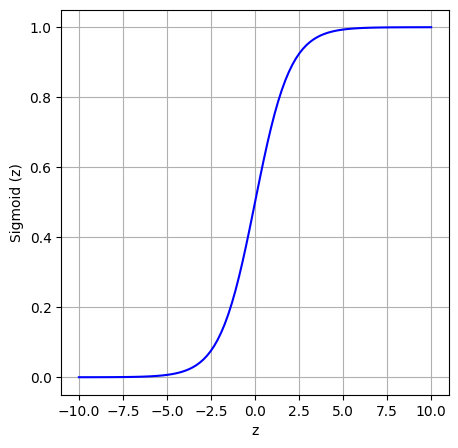

In [2]:
# Just like a linear regression model, a logistic regression model computes a weighted sum of the input features (plus a bias term),
# but instead of outputting the result directly like the linear regression model does, it outputs the logistic of this result.
# The logistic—denoted σ(·)—is a sigmoid function (i.e., S-shaped) that outputs a number between 0 and 1.

def sigmoid(z):
  return 1 / (1 + np.exp(-z))


zs = np.linspace(-10, 10, 100)

plt.figure(figsize=(5,5))
plt.plot(zs, sigmoid(zs), "-b")
plt.grid()
plt.ylabel("Sigmoid (z)")
plt.xlabel("z")


In [3]:
sigmoid(-2)

np.float64(0.11920292202211755)

Logistic regression is a linear model with a sigmoid likelihood:
$$p(y_i = 1 \vert X_i, w) = \sigma(X_i w),$$
$$p(y_i = 0 \vert X_i, w) = 1 - \sigma(X_i w),$$
$$L(w) = -\log(p(y \vert X, w)) =
-\sum_{i = 1}^N \log p(y_i | X_i, w) =
-\sum_{i = 1}^N \log\big [\sigma(X_i w) \cdot y_i + (1 - \sigma(X_i w))\cdot (1 - y_i)
\big ].$$

Because of the non-linearity $\sigma$, we cannot solve the logistic regression in closed form. We will have to use numerical optimization methods.

$$p(y_i = 1 \vert z_i) = \sigma(z_i),$$
$$p(y_i = 0 \vert z_i) = 1 - \sigma(z_i).$$

In [4]:
def plot_decision_boundary(X, y, model, title, ax, show_probabilities=True):
    """
    Plot decision boundary for a 2D dataset
    """
    # Create a mesh to plot the decision boundary
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), # create coordinate grid
                         np.arange(y_min, y_max, h))

    # Get predictions for the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()] # ravel() flattens a matrix into a 1D array and np.c_ means column-wise concatenate.
    if show_probabilities:
        Z = model.predict_proba(mesh_points)[:, 1]  # Probability of class 1
    else:
        Z = model.predict(mesh_points)

    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    if show_probabilities:
        # Show probability contours
        contour = ax.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
        # Add decision boundary line
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    else:
        ax.contourf(xx, yy, Z, levels=1, alpha=0.6, cmap='RdYlBu')

    # Plot the data points
    scatter = ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='o',
                        s=100, edgecolors='black', label='Class 0', alpha=0.8)
    scatter = ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='s',
                        s=100, edgecolors='black', label='Class 1', alpha=0.8)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Feature 1', fontweight='bold')
    ax.set_ylabel('Feature 2', fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    return contour if show_probabilities else None


Linear separable data accuracy: 0.9400
Model coefficients: [ 3.65042378 -0.4780839 ]
Model intercept: 0.0572


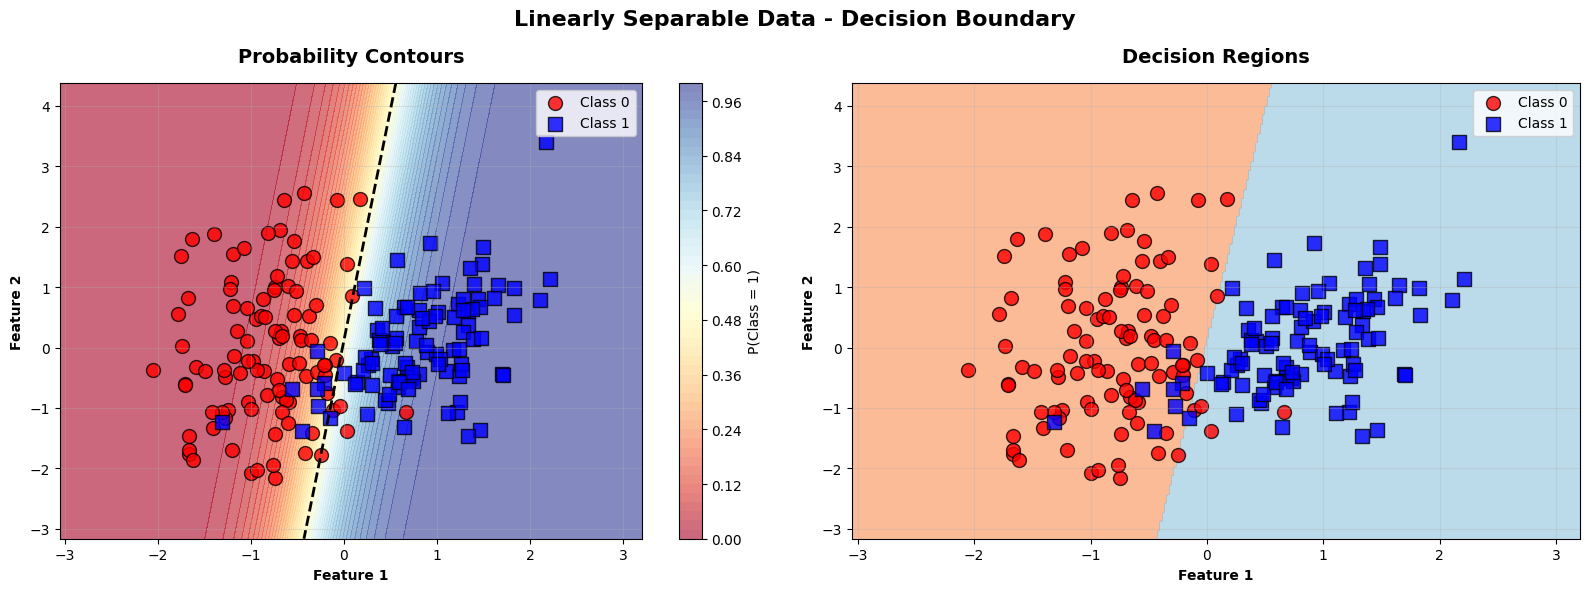

In [5]:
np.random.seed(42)

# Create a fake dataset for classification experiment
X_linear, y_linear = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                        n_informative=2, n_clusters_per_class=1,
                                        random_state=42, class_sep=1.5)

# Standardize features
scaler = StandardScaler()
X_linear_scaled = scaler.fit_transform(X_linear)

# Train logistic regression
model_linear = LogisticRegression(random_state=42)
model_linear.fit(X_linear_scaled, y_linear)

print(f"Linear separable data accuracy: {model_linear.score(X_linear_scaled, y_linear):.4f}")
print(f"Model coefficients: {model_linear.coef_[0]}")
print(f"Model intercept: {model_linear.intercept_[0]:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Linearly Separable Data - Decision Boundary', fontsize=16, fontweight='bold')

# Plot with probability contours
contour = plot_decision_boundary(X_linear_scaled, y_linear, model_linear,
                                'Probability Contours', axes[0], show_probabilities=True)
if contour:
    plt.colorbar(contour, ax=axes[0], label='P(Class = 1)')

# Plot with just decision regions
plot_decision_boundary(X_linear_scaled, y_linear, model_linear,
                      'Decision Regions', axes[1], show_probabilities=False)

plt.tight_layout()
plt.show()

The decision boundary is given by $x w = 0$, affine subspace in the feature spacew.

## What if data is not linear

Concentric Circles: Accuracy = 0.5100
Half Moons: Accuracy = 0.8450
Multiple Blobs: Accuracy = 1.0000


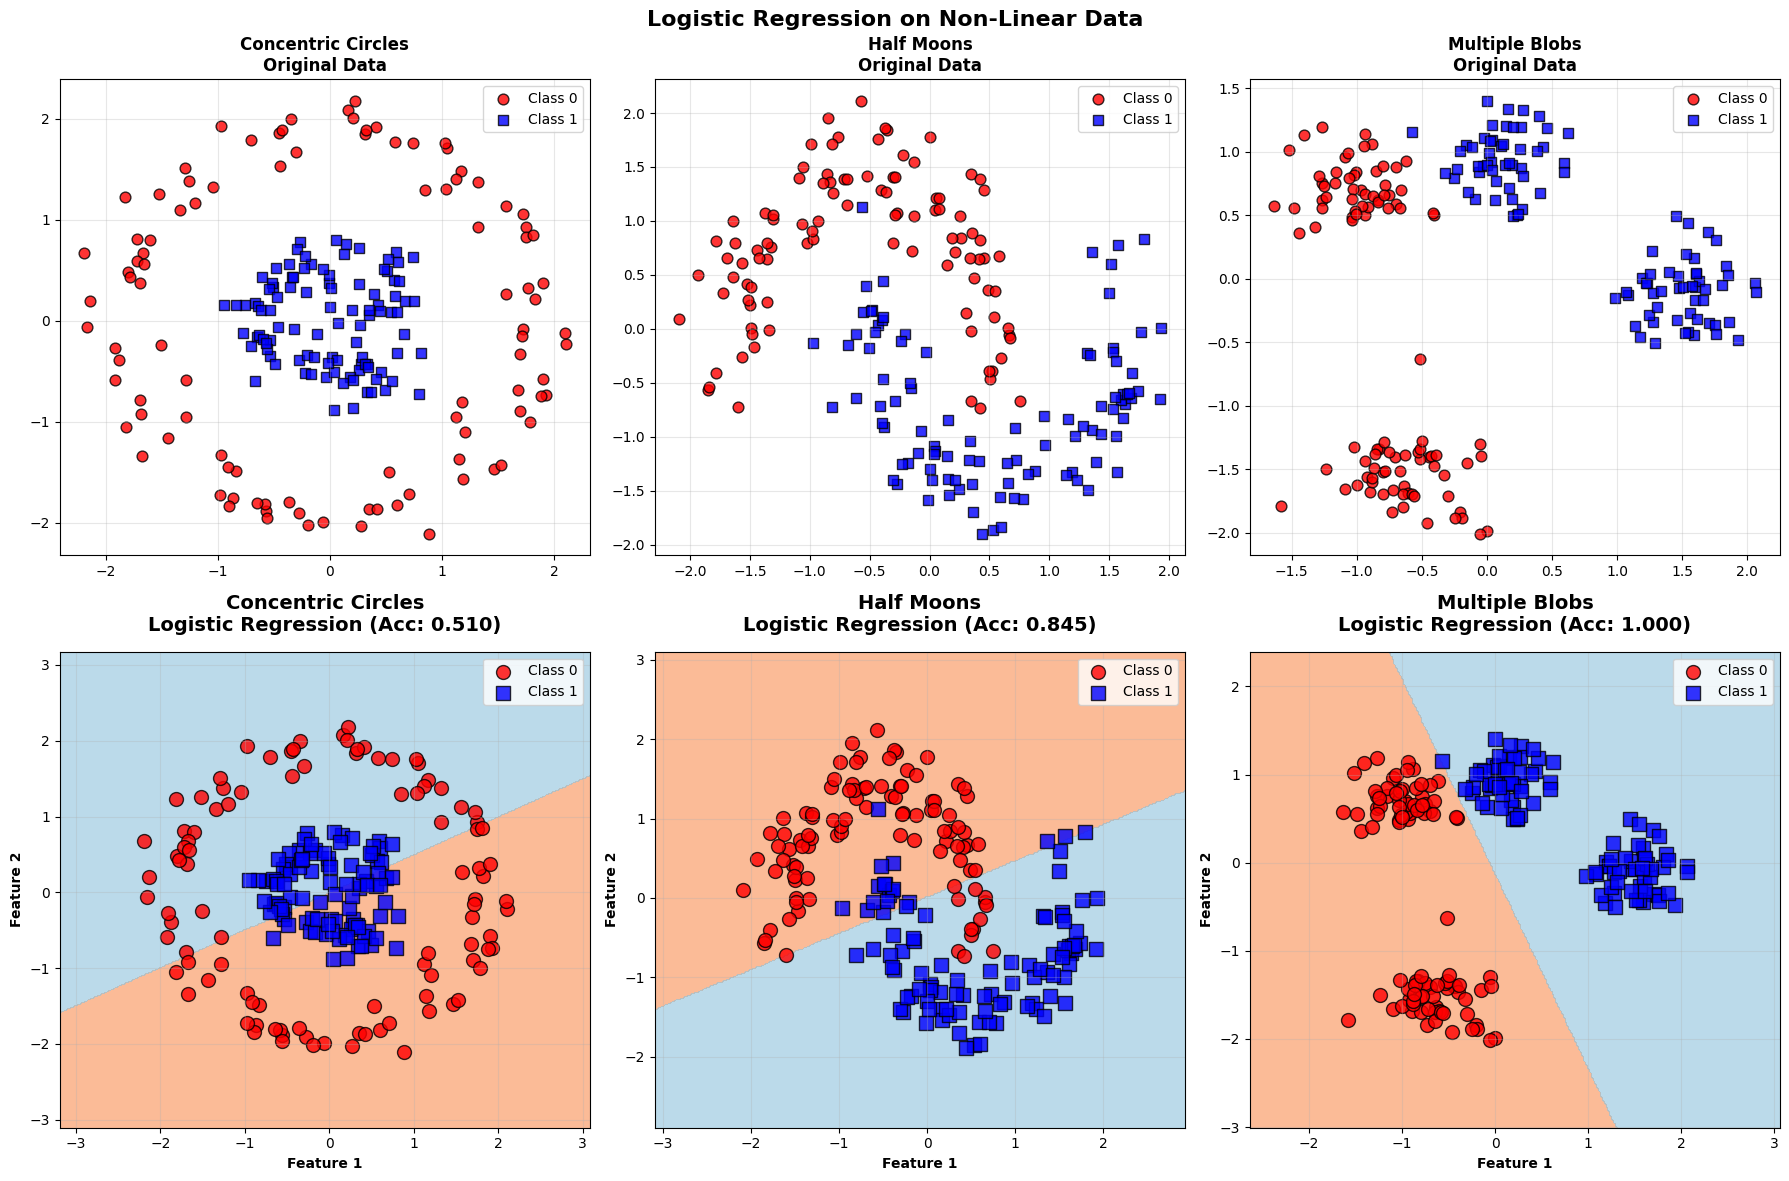

In [6]:
datasets = [
    make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=42),
    make_moons(n_samples=200, noise=0.15, random_state=42),
    make_blobs(n_samples=200, centers=4, n_features=2, cluster_std=1.5, random_state=42)
]

dataset_names = ['Concentric Circles', 'Half Moons', 'Multiple Blobs']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Logistic Regression on Non-Linear Data', fontsize=16, fontweight='bold')

for i, ((X, y), name) in enumerate(zip(datasets, dataset_names)): # zip() pairs elements from two lists -> ((X, y), name)
    # For blobs dataset, make it binary
    if i == 2:
        y = (y <= 1).astype(int)

    X_scaled = StandardScaler().fit_transform(X)
    model_nonlinear = LogisticRegression(random_state=42, max_iter=1000)
    model_nonlinear.fit(X_scaled, y)

    accuracy = model_nonlinear.score(X_scaled, y)

    # Plot original data
    axes[0, i].scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], c='red', marker='o',
                      s=60, edgecolors='black', label='Class 0', alpha=0.8)
    axes[0, i].scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], c='blue', marker='s',
                      s=60, edgecolors='black', label='Class 1', alpha=0.8)
    axes[0, i].set_title(f'{name}\nOriginal Data', fontsize=12, fontweight='bold')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    # Plot with decision boundary
    plot_decision_boundary(X_scaled, y, model_nonlinear,
                          f'{name}\nLogistic Regression (Acc: {accuracy:.3f})',
                          axes[1, i], show_probabilities=False)

    print(f"{name}: Accuracy = {accuracy:.4f}")

plt.tight_layout()
plt.show()

Let's add non-linear features. For the circles dataset we can use polynomial features

In [7]:
# Use the circles dataset and add polynomial features
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=42)
X_circles_scaled = StandardScaler().fit_transform(X_circles)

# Create polynomial features manually (manual implementation of PolynomialFeatures(degree=2))
def add_polynomial_features(X, degree=2):
    """Add polynomial features up to given degree"""
    X_poly = X.copy()

    if degree == 2:
        # Add squared terms
        X_poly = np.column_stack([X_poly, X[:, 0]**2, X[:, 1]**2])
        # Add interaction term
        X_poly = np.column_stack([X_poly, X[:, 0] * X[:, 1]])

    elif degree > 2:
        raise NotImplementedError

    return X_poly

X_circles_poly = add_polynomial_features(X_circles_scaled, degree=2)

# Train models
model_linear_circles = LogisticRegression(random_state=42, max_iter=1000)
model_linear_circles.fit(X_circles_scaled, y_circles)

model_poly_circles = LogisticRegression(random_state=42, max_iter=1000)
model_poly_circles.fit(X_circles_poly, y_circles)

acc_linear = model_linear_circles.score(X_circles_scaled, y_circles)
acc_poly = model_poly_circles.score(X_circles_poly, y_circles)

print(f"Linear features accuracy: {acc_linear:.4f}")
print(f"Polynomial features accuracy: {acc_poly:.4f}")
print(f"Improvement: {acc_poly - acc_linear:.4f}")

Linear features accuracy: 0.5100
Polynomial features accuracy: 1.0000
Improvement: 0.4900


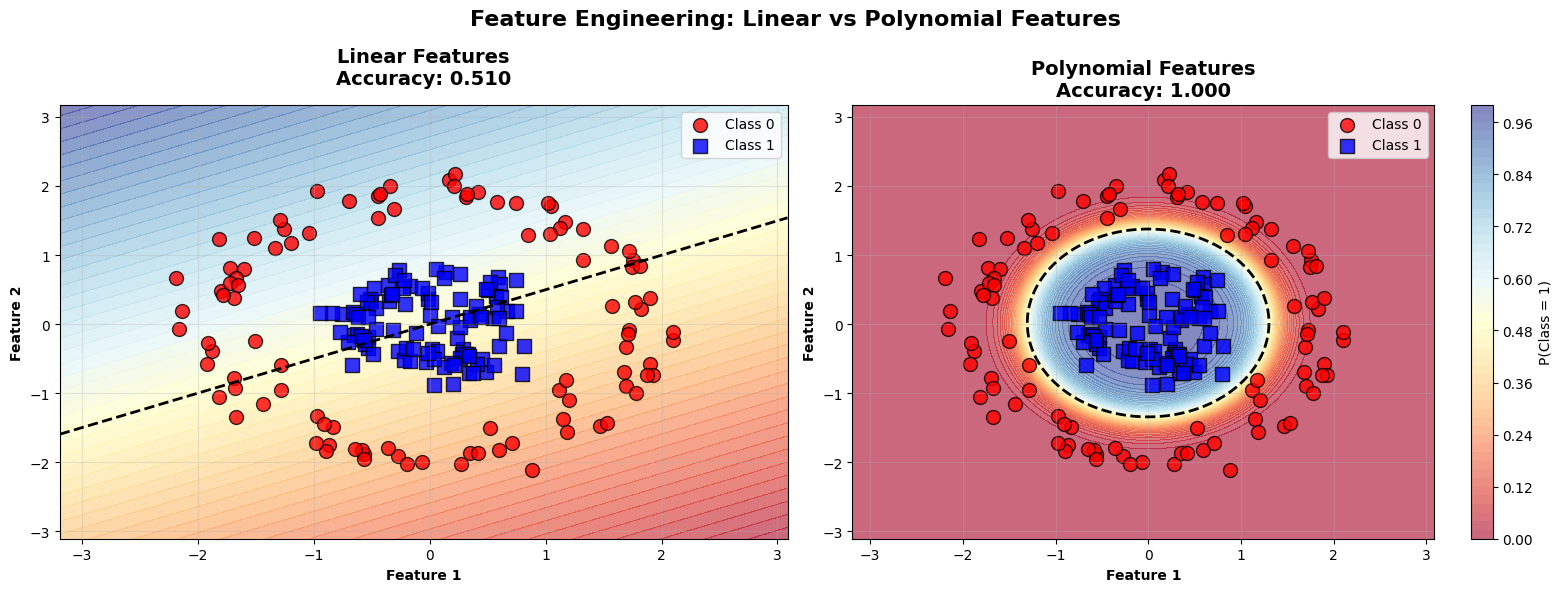

In [8]:
# For visualization, we need to create a mesh with polynomial features
def plot_polynomial_decision_boundary(X, y, model, title, ax):
    """Plot decision boundary for polynomial features"""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_poly = add_polynomial_features(mesh_points, degree=2)
    Z = model.predict_proba(mesh_poly)[:, 1].reshape(xx.shape)

    contour = ax.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='o',
              s=100, edgecolors='black', label='Class 0', alpha=0.8)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='s',
              s=100, edgecolors='black', label='Class 1', alpha=0.8)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1', fontweight='bold')
    ax.set_ylabel('Feature 2', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    return contour

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Engineering: Linear vs Polynomial Features', fontsize=16, fontweight='bold')

# Linear features
plot_decision_boundary(X_circles_scaled, y_circles, model_linear_circles,
                      f'Linear Features\nAccuracy: {acc_linear:.3f}',
                      axes[0], show_probabilities=True)

# Polynomial features
contour = plot_polynomial_decision_boundary(X_circles_scaled, y_circles, model_poly_circles,
                                          f'Polynomial Features\nAccuracy: {acc_poly:.3f}',
                                          axes[1])
plt.colorbar(contour, ax=axes[1], label='P(Class = 1)')

plt.tight_layout()
plt.show()

## Linear model equation

$$
P(y = 1 \mid x) = \sigma(w_1 x_1 + w_2 x_2 + b)
$$

### Decision boundary

$$
w_1 x_1 + w_2 x_2 + b = 0
$$

---

## Polynomial model equation

$$
P(y = 1 \mid x) =
\sigma\left(
w_1 x_1
+ w_2 x_2
+ w_3 x_1^2
+ w_4 x_2^2
+ w_5 x_1 x_2
+ b
\right)
$$

### Decision boundary

$$
w_1 x_1
+ w_2 x_2
+ w_3 x_1^2
+ w_4 x_2^2
+ w_5 x_1 x_2
+ b = 0
$$

## MNIST

In [9]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

print(f"✅ Dataset loaded successfully!")
print(f"   Shape of X: {X.shape}")
print(f"   Shape of y: {y.shape}")
print(f"   Unique classes: {np.unique(y)}")

✅ Dataset loaded successfully!
   Shape of X: (70000, 784)
   Shape of y: (70000,)
   Unique classes: [0 1 2 3 4 5 6 7 8 9]


Classification problem:[link text](https://)
$$x \in \mathbb{R}^{28^2},~~ y \in \{0, 1, \ldots, 9\}$$


MNIST images are:

28 pixels tall

28 pixels wide

Grayscale (1 channel)

So each image is a 28 × 28 grid.

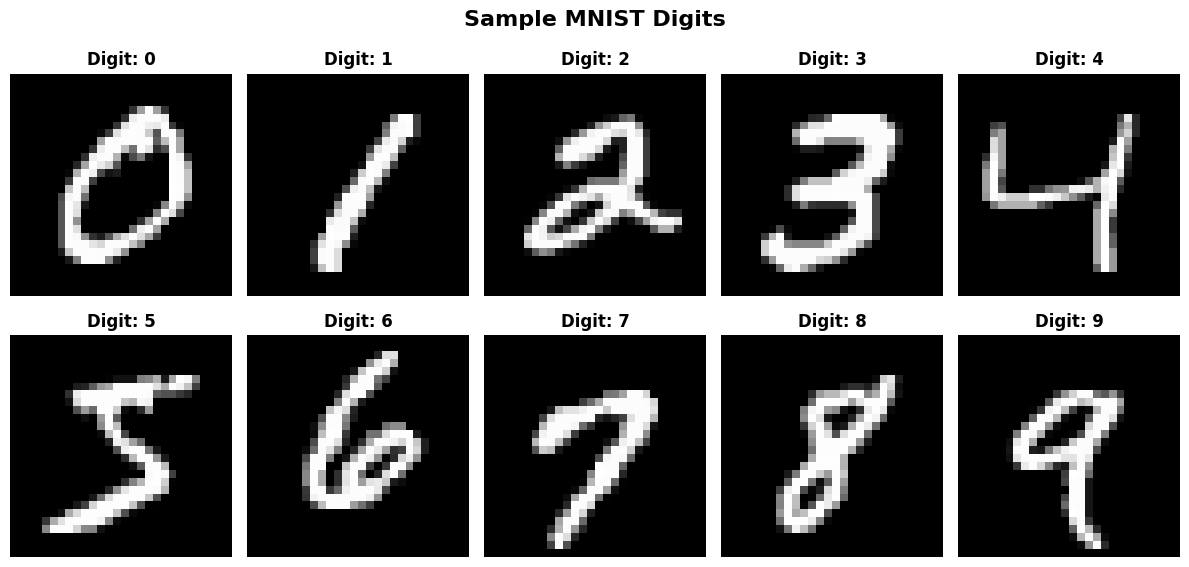

In [10]:
# Normalize pixel values to [0, 1]
X = X / 255.0 # Because MNIST pixel values are integers in: [0,255] 0 = black 255 = white

# Visualize some sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Digits', fontsize=16, fontweight='bold')

for i in range(10):
    row, col = i // 5, i % 5
    # Find first occurrence of digit i
    idx = np.where(y == i)[0][0]
    axes[row, col].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[row, col].set_title(f'Digit: {i}', fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

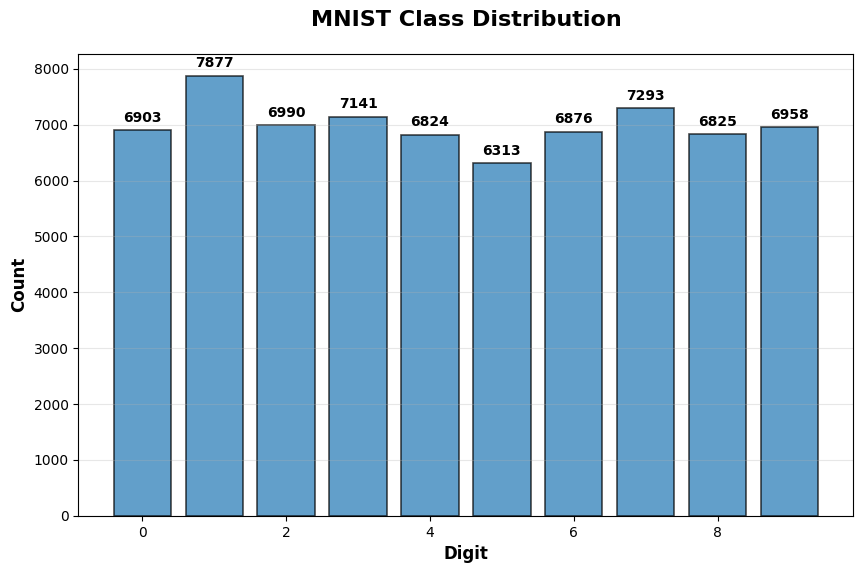

In [11]:
# Class distribution
plt.figure(figsize=(10, 6))
unique, counts = np.unique(y, return_counts=True)
bars = plt.bar(unique, counts, alpha=0.7, edgecolor='black', linewidth=1.2)
plt.title('MNIST Class Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Digit', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.show()

## Binary classification

Binary classification problem:
$$x \in \mathbb{R}^{28^2},~~ y \in \{0, 1\}.$$

We will convert our original MNIST classification problem to binary classification by changing the labels.

In [12]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = X_train, X_test, y_train > 4, y_test > 4

print(f"Training set: {X_train_bin.shape}")
print(f"Test set: {X_test_bin.shape}")
print(f"Class distribution: {np.bincount(y_train_bin)}")

Training set: (56000, 784)
Test set: (14000, 784)
Class distribution: [28684 27316]


In [13]:
# Train binary logistic regression
print("\n🔧 Training Binary Logistic Regression...")
binary_model = LogisticRegression(random_state=42, max_iter=1000)
binary_model.fit(X_train_bin, y_train_bin)

# Predictions and probabilities
y_pred_bin = binary_model.predict(X_test_bin)
y_prob_bin = binary_model.predict_proba(X_test_bin)

accuracy_bin = accuracy_score(y_test_bin, y_pred_bin)
print(f"✅ Binary Classification Accuracy: {accuracy_bin:.4f}")


🔧 Training Binary Logistic Regression...
✅ Binary Classification Accuracy: 0.8692


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

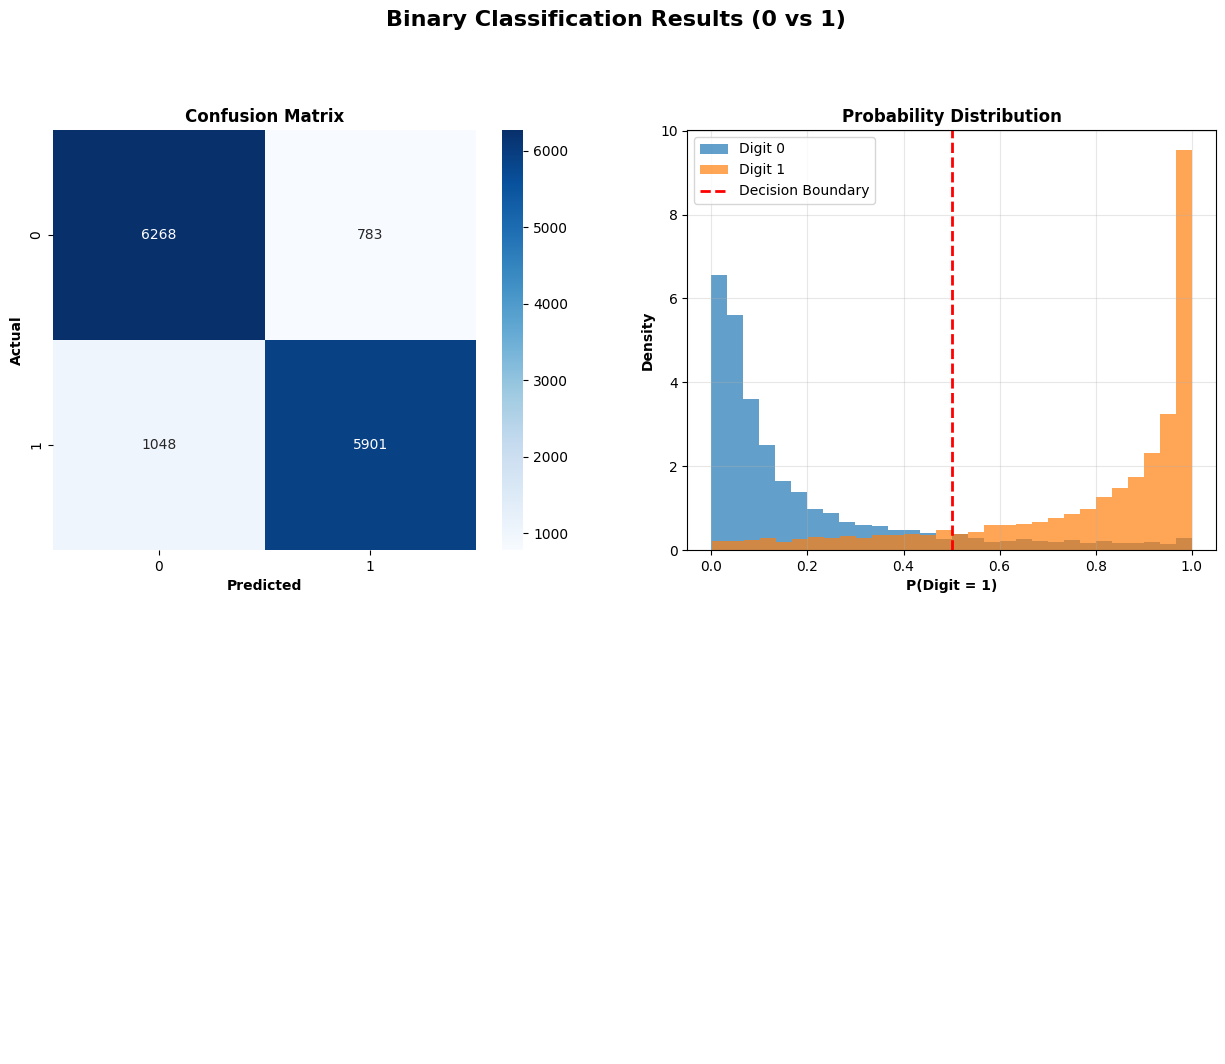

In [14]:
# Visualize binary classification results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Binary Classification Results (0 vs 1)', fontsize=16, fontweight='bold')

# Confusion Matrix
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['0', '1'], yticklabels=['0', '1'])
axes[0,0].set_title('Confusion Matrix', fontweight='bold')
axes[0,0].set_xlabel('Predicted', fontweight='bold')
axes[0,0].set_ylabel('Actual', fontweight='bold')

# Probability Distribution
axes[0,1].hist(y_prob_bin[y_test_bin == 0, 1], alpha=0.7, label='Digit 0', bins=30, density=True)
axes[0,1].hist(y_prob_bin[y_test_bin == 1, 1], alpha=0.7, label='Digit 1', bins=30, density=True)
axes[0,1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0,1].set_title('Probability Distribution', fontweight='bold')
axes[0,1].set_xlabel('P(Digit = 1)', fontweight='bold')
axes[0,1].set_ylabel('Density', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Sample predictions
sample_indices = np.random.choice(len(X_test_bin), 8, replace=False)
for i, idx in enumerate(sample_indices):
    row, col = (i // 4) + (0 if i < 4 else 1), i % 4
    if i < 4:
        ax = axes[1, 0] if i < 2 else axes[1, 1]
        subplot_idx = i % 2
    else:
        break

# Better sample visualization
axes[1,0].axis('off')
axes[1,1].axis('off')

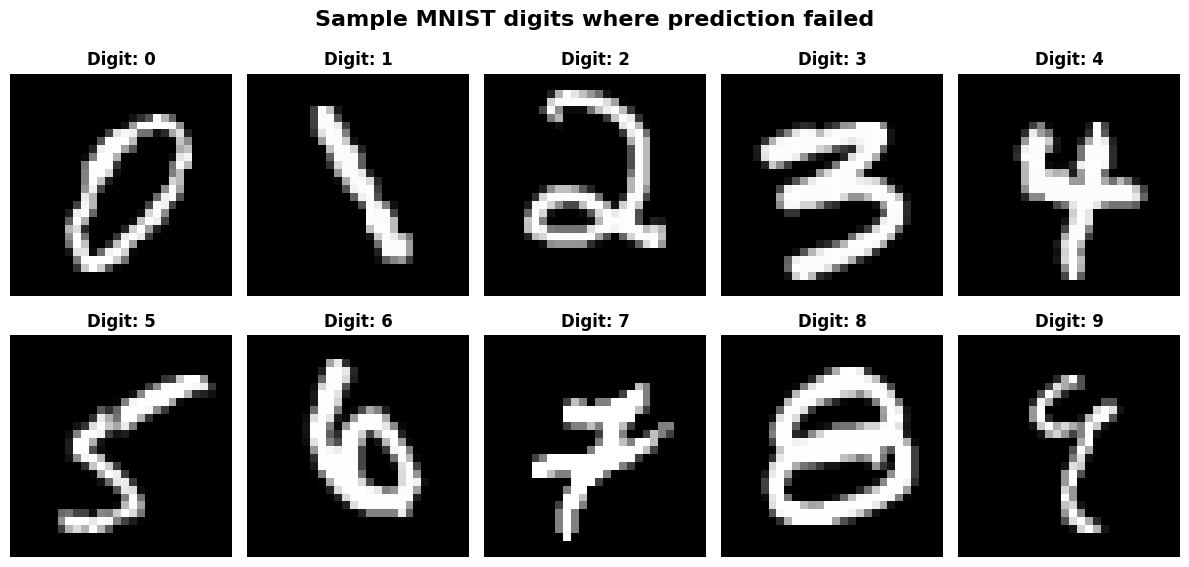

In [15]:
mask_wrong = (y_test_bin != y_pred_bin)

# Visualize some sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST digits where prediction failed', fontsize=16, fontweight='bold')

for i in range(10):
    row, col = i // 5, i % 5
    # Find first occurrence of digit i
    idx = np.where(y_test[mask_wrong] == i)[0][0]
    axes[row, col].imshow(X_test[mask_wrong][idx].reshape(28, 28), cmap='gray')
    axes[row, col].set_title(f'Digit: {i}', fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

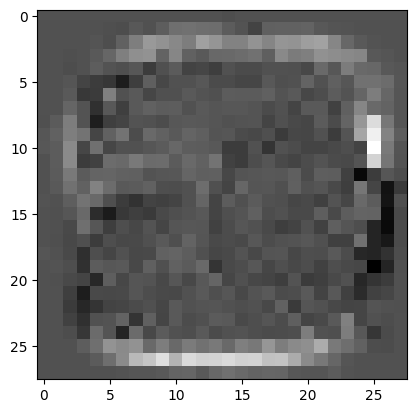

In [16]:
plt.imshow(binary_model.coef_.reshape(28, 28), cmap='gray')

Model has learned where strokes tend to appear
- Bright (positive weights): pushes prediction toward class 1 (digit ≥ 5)
- Dark (negative weights): pushes prediction toward class 0 (digit ≤ 4)
- Gray (~0): not important

## L2 Regularization

In [17]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_accuracies = []
test_accuracies = []

print("Testing different regularization strengths...")
for C in C_values:
    # Train model with specific C value (inverse of regularization strength) - mostly historical / convention
    # Logistic regression needs iterations because there is no closed-form solution
    model = LogisticRegression(C=C, random_state=42, max_iter=1000)
    model.fit(X_train_bin, y_train_bin)

    train_acc = model.score(X_train_bin, y_train_bin)
    test_acc = model.score(X_test_bin, y_test_bin)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"C = {C:7.3f}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

Testing different regularization strengths...
C =   0.001: Train Acc = 0.8394, Test Acc = 0.8394
C =   0.010: Train Acc = 0.8620, Test Acc = 0.8610
C =   0.100: Train Acc = 0.8712, Test Acc = 0.8690
C =   1.000: Train Acc = 0.8734, Test Acc = 0.8692
C =  10.000: Train Acc = 0.8737, Test Acc = 0.8699
C = 100.000: Train Acc = 0.8734, Test Acc = 0.8699
C = 1000.000: Train Acc = 0.8736, Test Acc = 0.8704


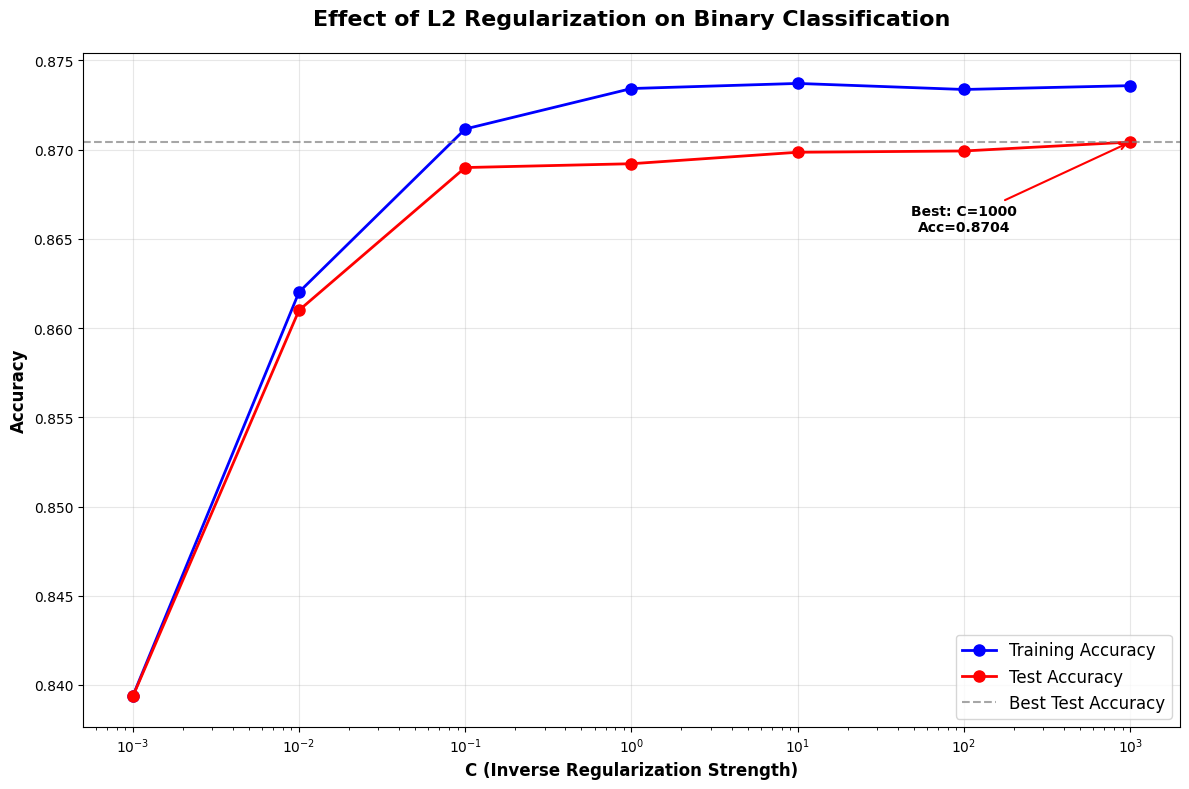

In [18]:
# Plot regularization effect
plt.figure(figsize=(12, 8))
plt.semilogx(C_values, train_accuracies, 'bo-', label='Training Accuracy', linewidth=2, markersize=8)
plt.semilogx(C_values, test_accuracies, 'ro-', label='Test Accuracy', linewidth=2, markersize=8)
plt.axhline(y=max(test_accuracies), color='gray', linestyle='--', alpha=0.7, label='Best Test Accuracy')

plt.title('Effect of L2 Regularization on Binary Classification', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('C (Inverse Regularization Strength)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Add annotations
best_C_idx = np.argmax(test_accuracies)
best_C = C_values[best_C_idx]
best_acc = test_accuracies[best_C_idx]
plt.annotate(f'Best: C={best_C}\nAcc={best_acc:.4f}',
             xy=(best_C, best_acc), xytext=(best_C*0.1, best_acc-0.005),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

## Multiclass Classification - All 10 Digits

Now we have $y_i \in \{0, 1, ..., C-1\}$. We will let the logits be $z_i \in \mathbb{R}^{C}$, where each component is a score for each class. Then, we need to normalize the scores so that they form a probability distribution over $y_i$.

$$p(y_i \vert z_i) = \text{softmax}(z_i).$$

Softmax is given by

$$
\text{softmax}(z_i) \in \mathbb{R}^{C},
$$
$$
\text{softmax}(z_i)_j = \frac{e^{z_i^j}}{\sum_{c=1}^{C} z_i^c}.
$$

Note that
$$
\sum_{c=1}^C \text{softmax}(z_i)_c = 1.
$$

Now, if we want to define a linear model for multiclass classification, we can do it as follows:
$$
z_i = X_i w,~~ p(y_i \vert z_i) = \text{softmax}(z_i)_{y_i}.
$$
where $X_i \in \mathbb{R}^{d}, w \in \mathbb{R}^{d \times C}, z_i \in \mathbb{R}^{C}, y_i \in \{0, 1, \ldots, C\}.$

In [19]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [24]:
multi_model = LogisticRegression(random_state=42, max_iter=1000, C=1) # same LogisticRegression(...) function, no need to specify binary vs multiclass
multi_model.fit(X_train_multi, y_train_multi)

# Predictions
y_pred_multi = multi_model.predict(X_test_multi)
# Probabilities
y_prob_multi = multi_model.predict_proba(X_test_multi)

accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
print(f"✅ Multiclass Classification Accuracy: {accuracy_multi:.4f}")

✅ Multiclass Classification Accuracy: 0.9210


In [30]:
# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_test_multi, y_pred_multi))


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2058
           1       0.95      0.97      0.96      2364
           2       0.92      0.90      0.91      2133
           3       0.90      0.89      0.90      2176
           4       0.92      0.93      0.92      1936
           5       0.89      0.88      0.89      1915
           6       0.94      0.95      0.95      2088
           7       0.93      0.94      0.94      2248
           8       0.89      0.87      0.88      1992
           9       0.90      0.90      0.90      2090

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000



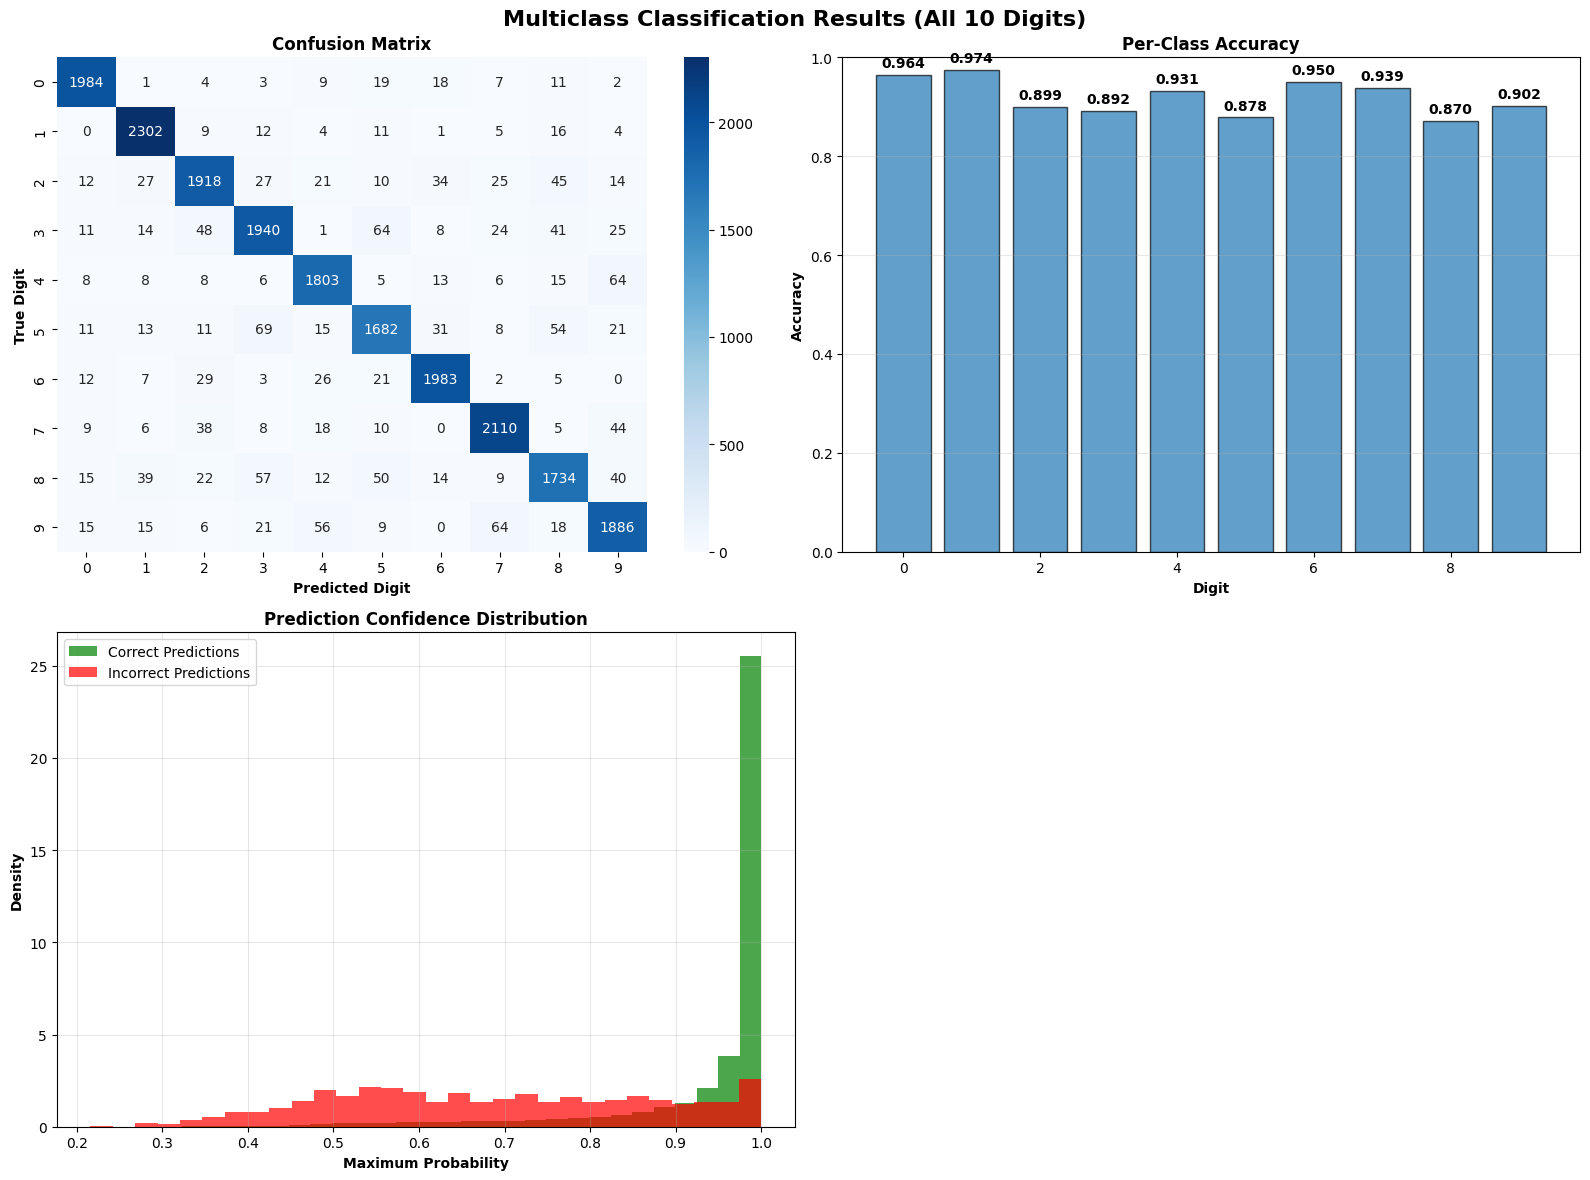

In [31]:
# Visualize multiclass results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multiclass Classification Results (All 10 Digits)', fontsize=16, fontweight='bold')

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix', fontweight='bold')
axes[0,0].set_xlabel('Predicted Digit', fontweight='bold')
axes[0,0].set_ylabel('True Digit', fontweight='bold')

# Per-class accuracy
class_accuracies = []
for i in range(10):
    mask = y_test_multi == i
    if np.sum(mask) > 0:
        acc = np.mean(y_pred_multi[mask] == i)
        class_accuracies.append(acc)
    else:
        class_accuracies.append(0)

bars = axes[0,1].bar(range(10), class_accuracies, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Per-Class Accuracy', fontweight='bold')
axes[0,1].set_xlabel('Digit', fontweight='bold')
axes[0,1].set_ylabel('Accuracy', fontweight='bold')
axes[0,1].set_ylim(0, 1)
axes[0,1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, class_accuracies)):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Prediction confidence distribution
max_probs = np.max(y_prob_multi, axis=1)
correct_mask = y_pred_multi == y_test_multi

axes[1,0].hist(max_probs[correct_mask], alpha=0.7, label='Correct Predictions',
               bins=30, density=True, color='green')
axes[1,0].hist(max_probs[~correct_mask], alpha=0.7, label='Incorrect Predictions',
               bins=30, density=True, color='red')
axes[1,0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[1,0].set_xlabel('Maximum Probability', fontweight='bold')
axes[1,0].set_ylabel('Density', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Sample of misclassified examples
incorrect_indices = np.where(y_pred_multi != y_test_multi)[0]
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

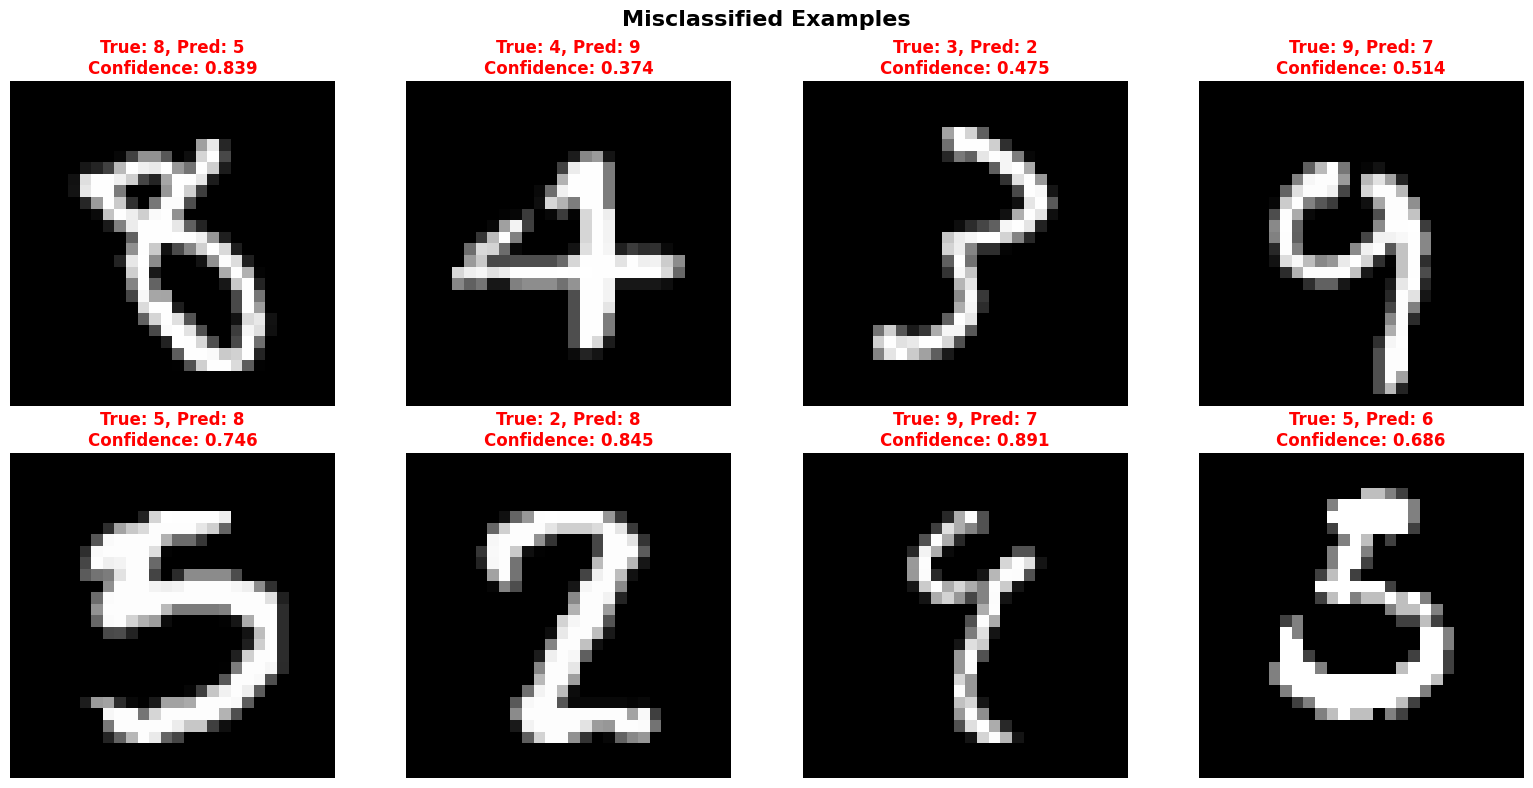

In [32]:
# Show misclassified examples
if len(incorrect_indices) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Misclassified Examples', fontsize=16, fontweight='bold')

    n_examples = min(8, len(incorrect_indices))
    for i in range(n_examples):
        row, col = i // 4, i % 4
        idx = incorrect_indices[i]

        axes[row, col].imshow(X_test_multi[idx].reshape(28, 28), cmap='gray')
        true_label = y_test_multi[idx]
        pred_label = y_pred_multi[idx]
        confidence = np.max(y_prob_multi[idx])

        axes[row, col].set_title(
            f'True: {true_label}, Pred: {pred_label}\nConfidence: {confidence:.3f}',
            color='red', fontweight='bold'
        )
        axes[row, col].axis('off')

    # Hide unused subplots
    for i in range(n_examples, 8):
        row, col = i // 4, i % 4
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()
